<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Dailychallenge_J2_W5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Comprendre les types de classification

### Classification Binaire
La classification binaire est une tâche de classification qui implique la prédiction d'une de deux classes. C'est le type de classification le plus simple, où chaque instance est assignée à l'une des deux catégories mutuellement exclusives.
**Exemple**: Prédire si un e-mail est un spam (1) ou non (0).

### Classification Multiclasse
La classification multiclasse est une tâche de classification qui implique la prédiction d'une de plus de deux classes. Dans ce cas, chaque instance est assignée à exactement une classe parmi un ensemble de classes mutuellement exclusives.
**Exemple**: Classer des images d'animaux en catégories comme 'chien', 'chat' ou 'oiseau'. Une image ne peut être qu'une seule de ces catégories.

### Classification Multi-étiquettes
La classification multi-étiquettes est une tâche de classification où chaque instance peut être associée à zéro, une ou plusieurs classes simultanément. Les classes ne sont pas mutuellement exclusives, ce qui signifie qu'une instance peut appartenir à plusieurs catégories en même temps.
**Exemple**: Taguer un film avec plusieurs genres, par exemple 'Action', 'Science-fiction' et 'Aventure'. Un seul film peut avoir plusieurs tags de genre.

## 2. Configurez votre environnement Python et votre jeu de données.

In [1]:
# Assurez-vous d'avoir installé les bibliothèques requises
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


In [2]:
# Il est temps de créer un ensemble de données sur lequel travailler :

samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('X (premières 5 lignes) : ')
print(X[:5])
print('\n')
print('y (premières 5 lignes) : ')
print(y[:5])

X (premières 5 lignes) : 
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


y (premières 5 lignes) : 
[1 1 1 1 0]


### Visualisation de l'ensemble de données
Visualisons l'ensemble de données à l'aide de nuages de points pour comprendre la distribution des données. Puisque nous avons un problème de classification binaire (0 ou 1), nous pouvons colorer les points en fonction de leur étiquette de classe.

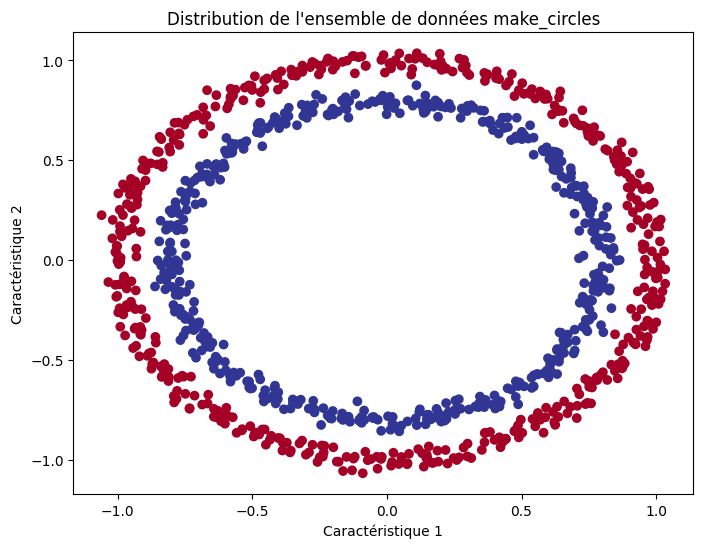

In [3]:
# Visualiser l'ensemble de données
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title("Distribution de l'ensemble de données make_circles")
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")
plt.show()

## 3. Construire un modèle de réseau neuronal de base

Nous allons créer un modèle séquentiel simple, le compiler avec l'entropie croisée binaire et l'entraîner.

In [4]:
# Fixer la graine aléatoire pour la reproductibilité
tf.random.set_seed(42)

# 1. Créer le modèle
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1) # Couche de base avec un seul neurone
])

# 2. Compiler le modèle
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['accuracy'])

# 3. Entraîner le modèle
print("Entraînement du modèle de base...")
model_1.fit(X, y, epochs=5, verbose=1)

Entraînement du modèle de base...
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4680 - loss: 4.3562
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4730 - loss: 2.4904
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4970 - loss: 0.7541
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4970 - loss: 0.7115
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4930 - loss: 0.7001


## 4 & 5. Amélioration du modèle et Visualisation de la frontière de décision

Nous allons créer un modèle plus complexe et définir une fonction pour visualiser comment le modèle sépare les classes.

In [5]:
# Fonction pour visualiser la frontière de décision
def plot_decision_boundary(model, X, y):
    # Définir les limites des axes
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Créer des prédictions
    x_in = np.c_[xx.ravel(), yy.ravel()]
    y_pred = model.predict(x_in)

    # Vérifier si c'est une classification binaire ou multiclasse
    if len(y_pred[0]) > 1:
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        y_pred = np.round(y_pred).reshape(xx.shape)

    # Tracer la frontière
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

Entraînement du modèle amélioré...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


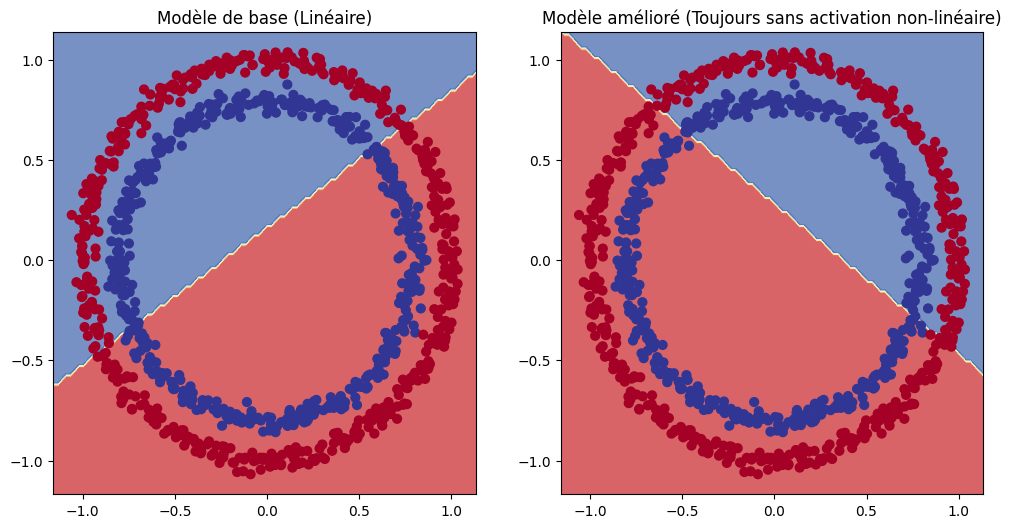

In [6]:
# Création d'un modèle amélioré
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(10), # Plus de neurones
  tf.keras.layers.Dense(10),
  tf.keras.layers.Dense(1)
])

model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), # Utilisation de Adam
                metrics=['accuracy'])

print("Entraînement du modèle amélioré...")
history = model_2.fit(X, y, epochs=20, verbose=0) # Plus d'époques

# Visualisation
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Modèle de base (Linéaire)")
plot_decision_boundary(model_1, X, y)
plt.subplot(1, 2, 2)
plt.title("Modèle amélioré (Toujours sans activation non-linéaire)")
plot_decision_boundary(model_2, X, y)
plt.show()

## 6, 7 & 8. Fonctions d'activation, Séparation des données et Évaluation finale

Pour capturer la forme circulaire, nous devons introduire des fonctions d'activation non-linéaires (ReLU). Nous allons également séparer nos données pour tester la capacité de généralisation du modèle.

Entraînement du modèle final avec ReLU...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0044  

Perte sur l'ensemble de test : 0.0044
Précision sur l'ensemble de test : 100.00%
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


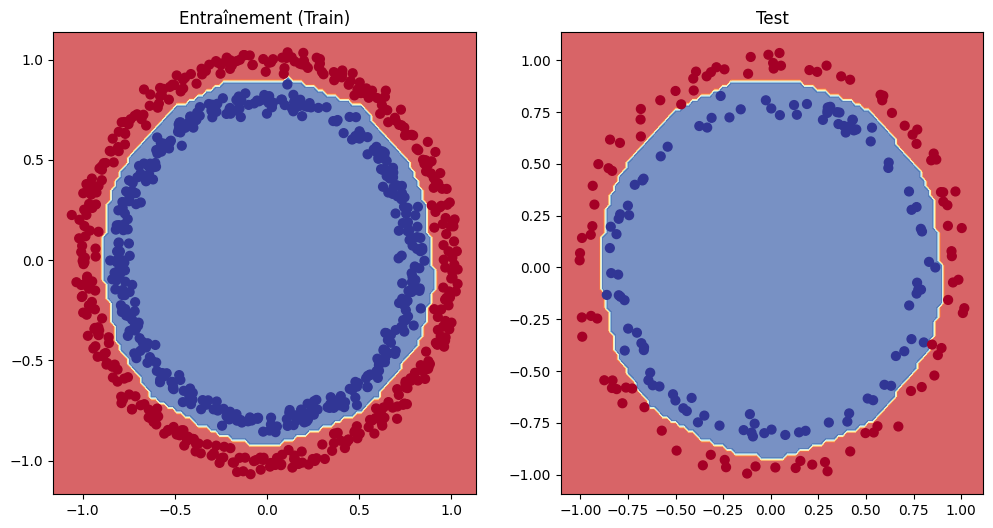

In [7]:
from sklearn.model_selection import train_test_split

# 7. Diviser les données en ensembles d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Créer le modèle avec fonctions d'activation
tf.random.set_seed(42)

model_final = tf.keras.Sequential([
  tf.keras.layers.Dense(10, activation='relu'), # Activation ReLU pour la non-linéarité
  tf.keras.layers.Dense(10, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid') # Sigmoïde en sortie pour une probabilité 0-1
])

# Compilation
model_final.compile(loss='binary_crossentropy',
                    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                    metrics=['accuracy'])

# Entraînement sur l'ensemble d'entraînement
print("Entraînement du modèle final avec ReLU...")
history = model_final.fit(X_train, y_train, epochs=100, verbose=0)

# 8. Évaluer et visualiser les performances
loss, accuracy = model_final.evaluate(X_test, y_test)
print(f"\nPerte sur l'ensemble de test : {loss:.4f}")
print(f"Précision sur l'ensemble de test : {accuracy*100:.2f}%")

# Visualisation des frontières de décision
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Entraînement (Train)")
plot_decision_boundary(model_final, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_final, X_test, y_test)
plt.show()

## 9. Résumé des points clés

### Ce que nous avons appris :
1. **Classification Binaire vs Multiclasse vs Multi-étiquettes** : Chaque problème nécessite une structure de sortie et une fonction de perte adaptées.
2. **Linéarité vs Non-linéarité** : Un réseau de neurones sans fonctions d'activation (comme ReLU) ne peut résoudre que des problèmes linéaires. Pour des données circulaires, la non-linéarité est indispensable.
3. **Visualisation des données** : Tracer les frontières de décision nous a permis de comprendre visuellement pourquoi le premier modèle échouait (il traçait une ligne droite au lieu d'un cercle).
4. **Réglage des hyperparamètres** : Le choix de l'optimiseur (Adam), du nombre de couches, et du nombre d'époques influence directement la capacité du modèle à converger vers une solution optimale.
5. **Généralisation** : La division Train/Test est essentielle pour s'assurer que le modèle ne fait pas de surapprentissage (overfitting) et qu'il fonctionne sur de nouvelles données.